In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from damd.visualization.plotter import VMDVisualizer
from damd.visualization.config import VisualizationConfig, FontConfig, LegendConfig, SaveConfig
from damd.core.decomposition import DAMD
from damd.core.config import DAMDConfig, BandwidthConfig
from ssqueezepy.experimental import scale_to_freq
from ssqueezepy import irfft, fftshift
from scipy.signal import istft
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec

In [2]:
def main(signal, fs, method_band='adaptive', method_mode='dme', transform_type = 'stft', t_mode=[0,0.5,1]):
    # Configure bandwidth estimation
    config_bandw = BandwidthConfig(
        method=method_band,
        scale_factor=1.0,
        base_method='silverman',
        min_bandwidth=1e-6,
        seed_spacing=5
    )

    # Configure DAMD
    config_vmd = DAMDConfig(
        num_channels=1,
        n_fft=fs//2,
        alpha=50,
        tol=1e-8,
        tau=0.00001,
        max_iterations=100,
        modulated=True,
        rho_thresh=0.0,
        method=method_mode,
        keep_residual=False
    )

    # Initialize VMD
    vmd = DAMD(config_vmd, config_bandw)
    
    # Transform signal to TF domain
    signal_expanded = signal.reshape(1, -1)
    tf_map, scale = vmd.transformer.transform(signal_expanded, transform_type=transform_type)
    
    if transform_type=='cwt' or transform_type=='ssq_cwt':
        scale = scale_to_freq(scale, 'gmw', len(signal), fs=fs)
    # Decompose signal
    result = vmd.decompose(tf_map, t_modes=t_mode)
    # result = vmd.generate_time_domain_modes(result, transform_type)
    return result,vmd,scale

In [3]:
addfontsize = 4
# You can also customize base font sizes and then scale them
config = VisualizationConfig(
    base_fonts=FontConfig(
        base_font=12+addfontsize,
        base_title=14+addfontsize,
        base_label=12+addfontsize,
        base_tick=12+addfontsize,
        base_legend=10+addfontsize
    ),
    font_scale=1.2,  # These base sizes will be scaled by 1.2
    # tf_legend=LegendConfig(
    #     location='upper left'
    # ),
    centers_legend=LegendConfig(
        location='upper right',
        framealpha=0.7
    ),
    signal_legend=LegendConfig(
        location=(0.6, -0.02),  # Lower right
        ncol=2,
        frameon=False  # No frame
    ),
    save_config=SaveConfig(
        format='svg',
        transparent=True  # Transparent background
    )
)

In [4]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
data=loadmat('sample.mat')['eeg']
mdata = data.mean(-1)
fs =250
t=np.arange(fs*2*5)/250

f = np.concatenate((mdata[2,7,:], mdata[5,7,:]), axis=-1)
signal = f/f.max()

In [5]:
result,vmd,scale = main(signal, fs, 
                            method_band='percentile', 
                            method_mode='dme', 
                            transform_type='ssq_cwt')

Selected decomposition method: dme


DME Processing: 100%|██████████| 2500/2500 [00:14<00:00, 170.60it/s]


In [6]:
freq_points = np.linspace(0, fs/2, 237)

In [7]:
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from matplotlib.gridspec import GridSpec

from damd.core.config import ProcessingResult

In [8]:
def _calculate_mode_energies(modes: list) -> np.ndarray:
    """Calculate energy for each mode."""
    energies = []
    for mode in modes:
        if isinstance(mode, np.ndarray):
            energy = np.mean(np.abs(mode)**2)
            energies.append(energy)
        else:
            energies.append(0)
    return np.array(energies)

In [9]:
def _plot_tf_original(ax: Axes,
                        result: ProcessingResult,
                        fs: float,
                        title=None) -> None:
    """Plot original time-frequency map."""
    tf_energy = np.abs(result.tf_map)[0]
    time_points = np.arange(tf_energy.shape[1]) / fs
    freq_points = np.linspace(0, fs/2, tf_energy.shape[0])
    
    im = ax.pcolormesh(time_points, freq_points, tf_energy,
                       cmap=config.color_palette,
                    shading='gouraud')
    
    if title is not None:
        ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    plt.colorbar(im, ax=ax, label='Energy')
    
def _plot_tf_centers(ax: Axes,
                    result: ProcessingResult,
                    fs: float,
                    title=None) -> None:
    """Plot center frequencies with energy-based markers."""
    # Calculate mode energies for marker sizing
    mode_energies = _calculate_mode_energies(result.mode_functions)
    normalized_energies = mode_energies / np.max(mode_energies)
    
    # Get time-frequency coordinates
    times = np.array(result.time_indices) / fs
    freqs = np.array(result.center_frequencies) * fs/2
    
    # Create empty background matching the original TF plot
    tf_energy = result.compute_tf_energy()
    time_points = np.arange(tf_energy.shape[1]) / fs
    freq_points = np.linspace(0, fs/2, tf_energy.shape[0])
    ax.pcolormesh(time_points, freq_points, np.zeros_like(tf_energy),
                    cmap='Greys', alpha=0.1)
    
    # Plot center frequencies
    scatter_sizes = normalized_energies * config.marker_base_size
    ax.scatter(times, freqs, 
                s=scatter_sizes,
                c=config.marker_color,
                alpha=config.marker_alpha,
                edgecolors=config.marker_edge_color,
                linewidth=0.5)
    
    if title is not None:
        ax.set_title(title)
    # ax.set_title('Mode Center Frequencies')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    # ax.legend()
    
    # Match limits with original TF plot
    ax.set_xlim(time_points[0], time_points[-1])
    ax.set_ylim(freq_points[0], freq_points[-1])

In [10]:
t.shape

(2500,)

In [11]:
signal.shape

(2500,)

In [12]:
import matplotlib

In [13]:
# 全局设置中文字体
matplotlib.rcParams['font.family'] = 'SimSun'
matplotlib.rcParams['font.sans-serif'] = ['SimSun']
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

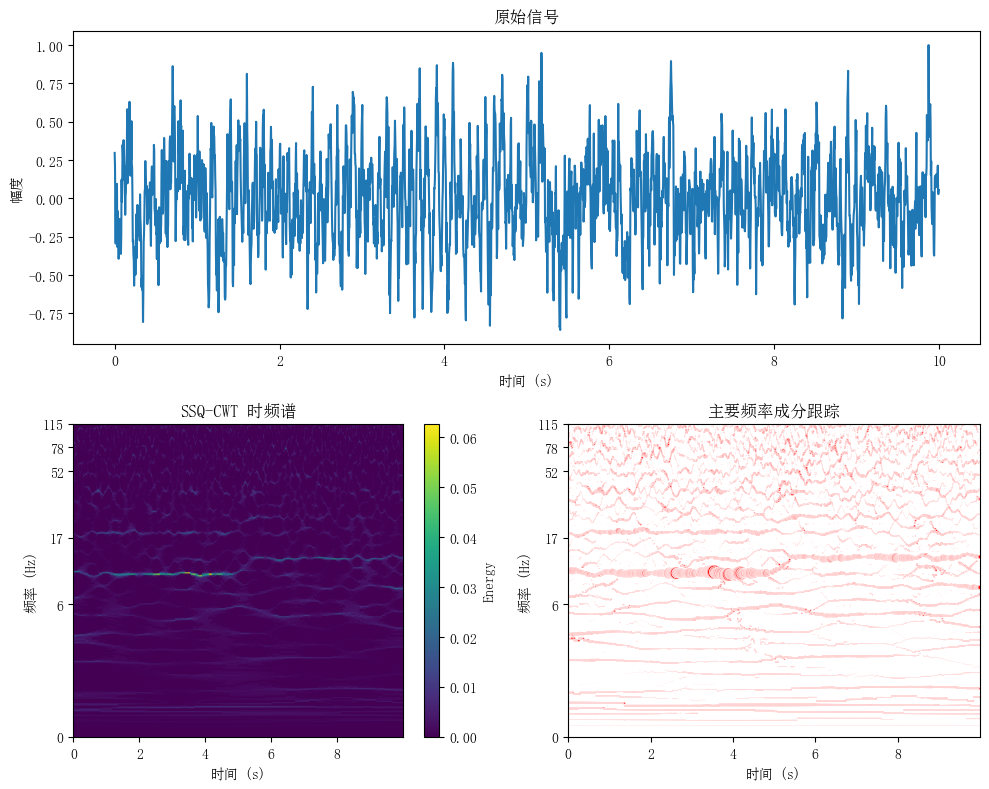

In [14]:
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2)

ax_org = fig.add_subplot(gs[0, :])
ax_org.plot(t, signal)
ax_org.set_title('原始信号')  # 添加中文标题
ax_org.set_xlabel('时间 (s)')  # 中文x轴标签
ax_org.set_ylabel('幅度')     # 中文y轴标签

ax_tf = fig.add_subplot(gs[1, 0])
_plot_tf_original(ax_tf, result, fs)
ax_tf.set_title('SSQ-CWT 时频谱')  # 中文标题
ax_tf.set_xlabel('时间 (s)')      # 中文x轴标签
ax_tf.set_ylabel('频率 (Hz)')     # 中文y轴标签
ax_tf.set_yticks(freq_points[[0,100,150,200,218,236]])
ax_tf.set_yticklabels(np.array(scale[::-1][[0,100,150,200,218,236]], dtype=int))

ax_tf_centers = fig.add_subplot(gs[1, 1])
_plot_tf_centers(ax_tf_centers, result, fs, title='主要频率成分跟踪')
ax_tf_centers.set_xlabel('时间 (s)')
ax_tf_centers.set_ylabel('频率 (Hz)')
ax_tf_centers.set_yticks(freq_points[[0,100,150,200,218,236]])
ax_tf_centers.set_yticklabels(np.array(scale[::-1][[0,100,150,200,218,236]], dtype=int))

plt.tight_layout()

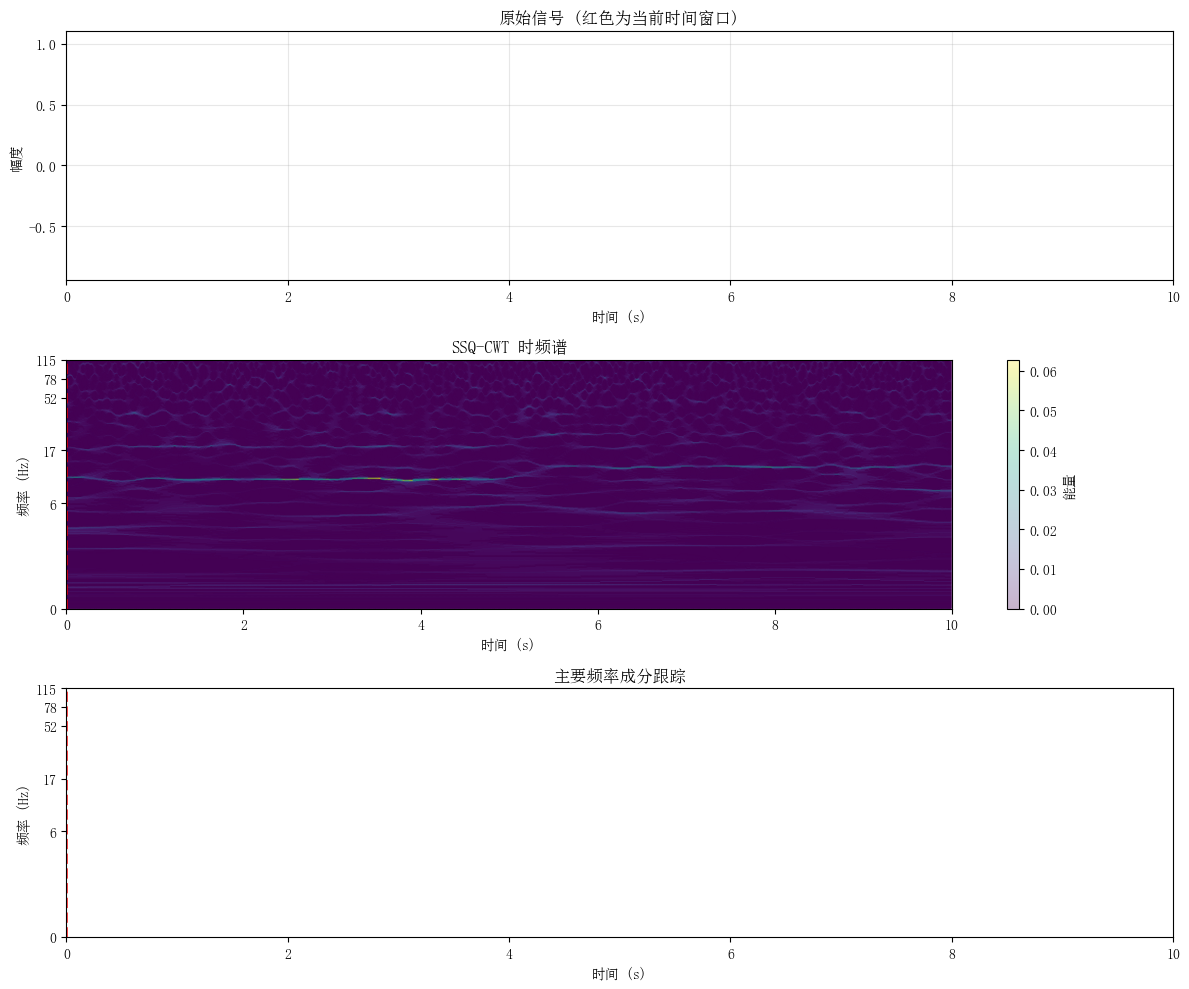

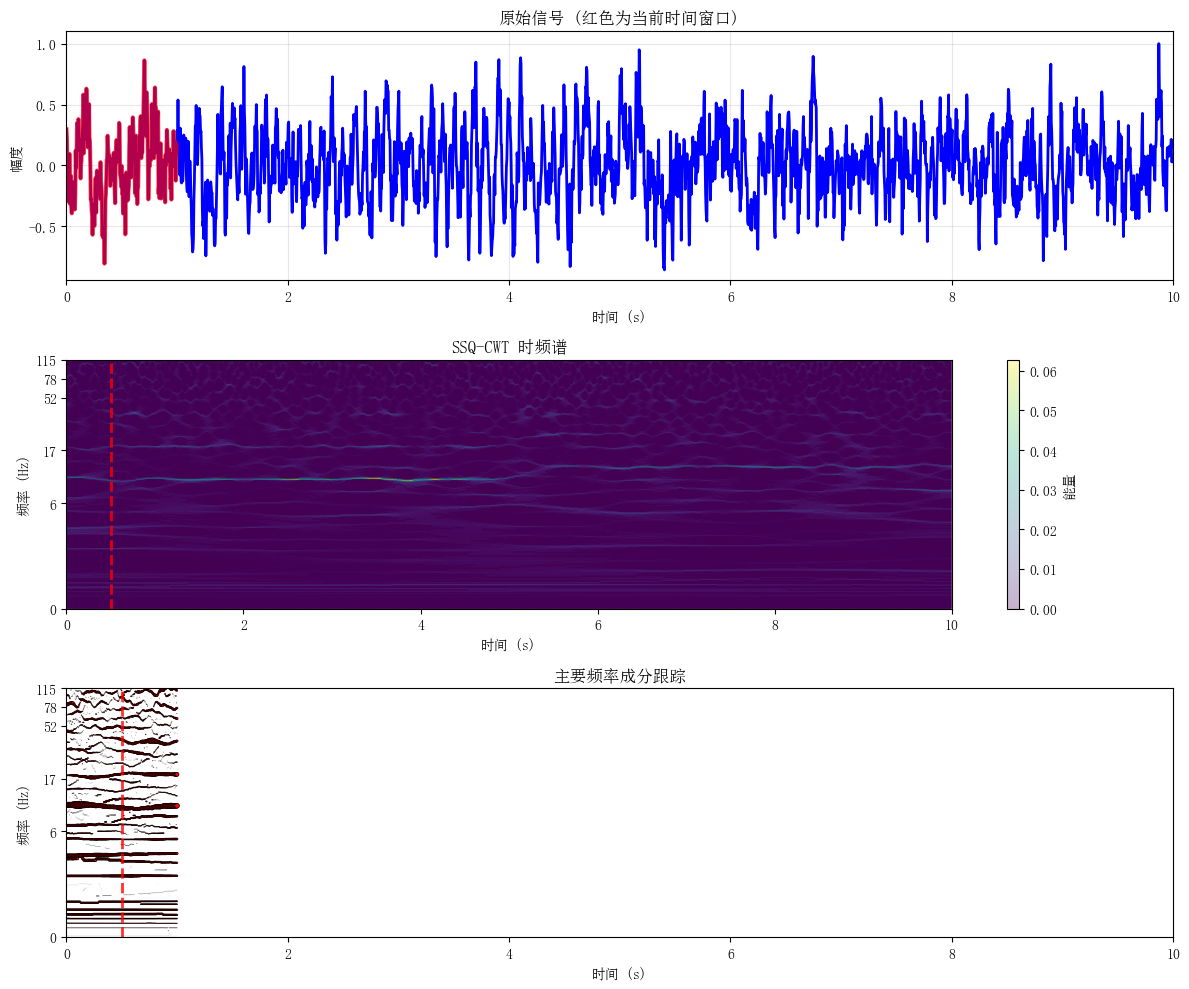

In [15]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from matplotlib.gridspec import GridSpec

# 全局设置中文字体
import matplotlib
matplotlib.rcParams['font.family'] = 'SimSun'
matplotlib.rcParams['font.sans-serif'] = ['SimSun']
matplotlib.rcParams['axes.unicode_minus'] = False

def create_animated_plot(signal, t, result, fs, scale, freq_points, 
                        window_size=1.0, step_size=0.1, interval=200):
    """
    创建时频分析动画
    
    参数:
    - signal: 原始信号
    - t: 时间轴
    - result: VMD分解结果
    - fs: 采样频率
    - scale: 频率尺度
    - freq_points: 频率点
    - window_size: 时间窗口大小(秒)
    - step_size: 时间步长(秒)
    - interval: 动画间隔(毫秒)
    """
    
    # 计算时间窗口参数
    total_time = len(signal) / fs
    window_samples = int(window_size * fs)
    step_samples = int(step_size * fs)
    
    # 创建时间点序列
    time_points = np.arange(0, total_time - window_size + step_size, step_size)
    
    # 准备数据
    tf_energy = np.abs(result.tf_map)[0]
    mode_energies = _calculate_mode_energies(result.mode_functions)
    normalized_energies = mode_energies / np.max(mode_energies)
    
    # 创建图形
    fig = plt.figure(figsize=(12, 10))
    gs = GridSpec(3, 1, height_ratios=[1, 1, 1])
    
    # 三个子图
    ax_signal = fig.add_subplot(gs[0])
    ax_tf = fig.add_subplot(gs[1])
    ax_centers = fig.add_subplot(gs[2])
    
    # 初始化图形元素
    line_signal, = ax_signal.plot([], [], 'b-', linewidth=2)
    line_window, = ax_signal.plot([], [], 'r-', linewidth=3, alpha=0.7)
    
    # 时频图
    time_tf = np.arange(tf_energy.shape[1]) / fs
    freq_tf = np.linspace(0, fs/2, tf_energy.shape[0])
    
    # 初始化空图
    im_tf = ax_tf.pcolormesh(time_tf, freq_tf, tf_energy, 
                            cmap='viridis', shading='gouraud', alpha=0.3)
    
    # 中心频率散点图
    im_centers = ax_centers.pcolormesh(time_tf, freq_tf, np.zeros_like(tf_energy),
                                      cmap='Greys', alpha=0.1)
    
    # 设置坐标轴
    ax_signal.set_xlim(0, total_time)
    ax_signal.set_ylim(signal.min() * 1.1, signal.max() * 1.1)
    ax_signal.set_title('原始信号 (红色为当前时间窗口)')
    ax_signal.set_xlabel('时间 (s)')
    ax_signal.set_ylabel('幅度')
    ax_signal.grid(True, alpha=0.3)
    
    ax_tf.set_xlim(0, total_time)
    ax_tf.set_ylim(freq_tf[0], freq_tf[-1])
    ax_tf.set_title('SSQ-CWT 时频谱')
    ax_tf.set_xlabel('时间 (s)')
    ax_tf.set_ylabel('频率 (Hz)')
    ax_tf.set_yticks(freq_points[[0,100,150,200,218,236]])
    ax_tf.set_yticklabels(np.array(scale[::-1][[0,100,150,200,218,236]], dtype=int))
    
    ax_centers.set_xlim(0, total_time)
    ax_centers.set_ylim(freq_tf[0], freq_tf[-1])
    ax_centers.set_title('主要频率成分跟踪')
    ax_centers.set_xlabel('时间 (s)')
    ax_centers.set_ylabel('频率 (Hz)')
    ax_centers.set_yticks(freq_points[[0,100,150,200,218,236]])
    ax_centers.set_yticklabels(np.array(scale[::-1][[0,100,150,200,218,236]], dtype=int))
    
    # 添加颜色条
    plt.colorbar(im_tf, ax=ax_tf, label='能量')
    
    # 时间窗口指示线
    vline_tf = ax_tf.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.8)
    vline_centers = ax_centers.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.8)
    
    # 存储散点图对象
    scatter_obj = None
    
    def animate(frame):
        nonlocal scatter_obj
        
        # 计算当前时间窗口
        current_time = time_points[frame]
        start_idx = int(current_time * fs)
        end_idx = start_idx + window_samples
        
        # 更新原始信号图
        line_signal.set_data(t, signal)
        
        # 更新时间窗口高亮
        if end_idx <= len(signal):
            window_t = t[start_idx:end_idx]
            window_signal = signal[start_idx:end_idx]
            line_window.set_data(window_t, window_signal)
        
        # 更新时频图的时间指示线
        vline_tf.set_xdata([current_time + window_size/2])
        vline_centers.set_xdata([current_time + window_size/2])
        
        # 更新中心频率散点图 - 只显示当前时间窗口内的点
        if hasattr(result, 'time_indices') and hasattr(result, 'center_frequencies'):
            times = np.array(result.time_indices) / fs
            freqs = np.array(result.center_frequencies) * fs/2
            
            # 筛选当前时间窗口内的点
            mask = (times >= current_time) & (times <= current_time + window_size)
            
            # 清除之前的散点
            if scatter_obj is not None:
                scatter_obj.remove()
            
            if np.any(mask):
                current_times = times[mask]
                current_freqs = freqs[mask]
                current_energies = normalized_energies[mask] if len(normalized_energies) > 0 else np.ones(len(current_times))
                
                scatter_sizes = current_energies * config.marker_base_size if 'config' in globals() else current_energies * 50
                scatter_obj = ax_centers.scatter(current_times, current_freqs,
                                               s=scatter_sizes,
                                               c='red',
                                               alpha=0.8,
                                               edgecolors='black',
                                               linewidth=0.5)
        
        return line_signal, line_window, vline_tf, vline_centers
    
    # 创建动画
    anim = animation.FuncAnimation(fig, animate, frames=len(time_points),
                                 interval=interval, blit=False, repeat=True)
    
    plt.tight_layout()
    return fig, anim

# 使用示例
def save_animation(signal, t, result, fs, scale, freq_points, 
                  filename='tf_analysis_animation.gif', 
                  fps=5, window_size=1.0):
    """
    保存动画为GIF或MP4
    """
    fig, anim = create_animated_plot(signal, t, result, fs, scale, freq_points,
                                   window_size=window_size, 
                                   step_size=window_size/10,
                                   interval=1000/fps)
    
    # 保存为GIF
    if filename.endswith('.gif'):
        anim.save(filename, writer='pillow', fps=fps)
    # 保存为MP4 (需要ffmpeg)
    elif filename.endswith('.mp4'):
        anim.save(filename, writer='ffmpeg', fps=fps)
    
    return fig, anim

# 调用函数创建动画
fig, anim = create_animated_plot(signal, t, result, fs, scale, freq_points,
                               window_size=1.0,    # 1秒时间窗口
                               step_size=0.1,      # 0.1秒步长
                               interval=200)       # 200毫秒间隔

# 显示动画
plt.show()

# 如果要保存动画，取消注释下面的行
fig_save, anim_save = save_animation(signal, t, result, fs, scale, freq_points,
                                    'tf_analysis.gif', fps=10, window_size=1.0)

c:\Users\spikage\miniconda3\envs\acvmd\lib\site-packages\matplotlib\animation.py:884: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


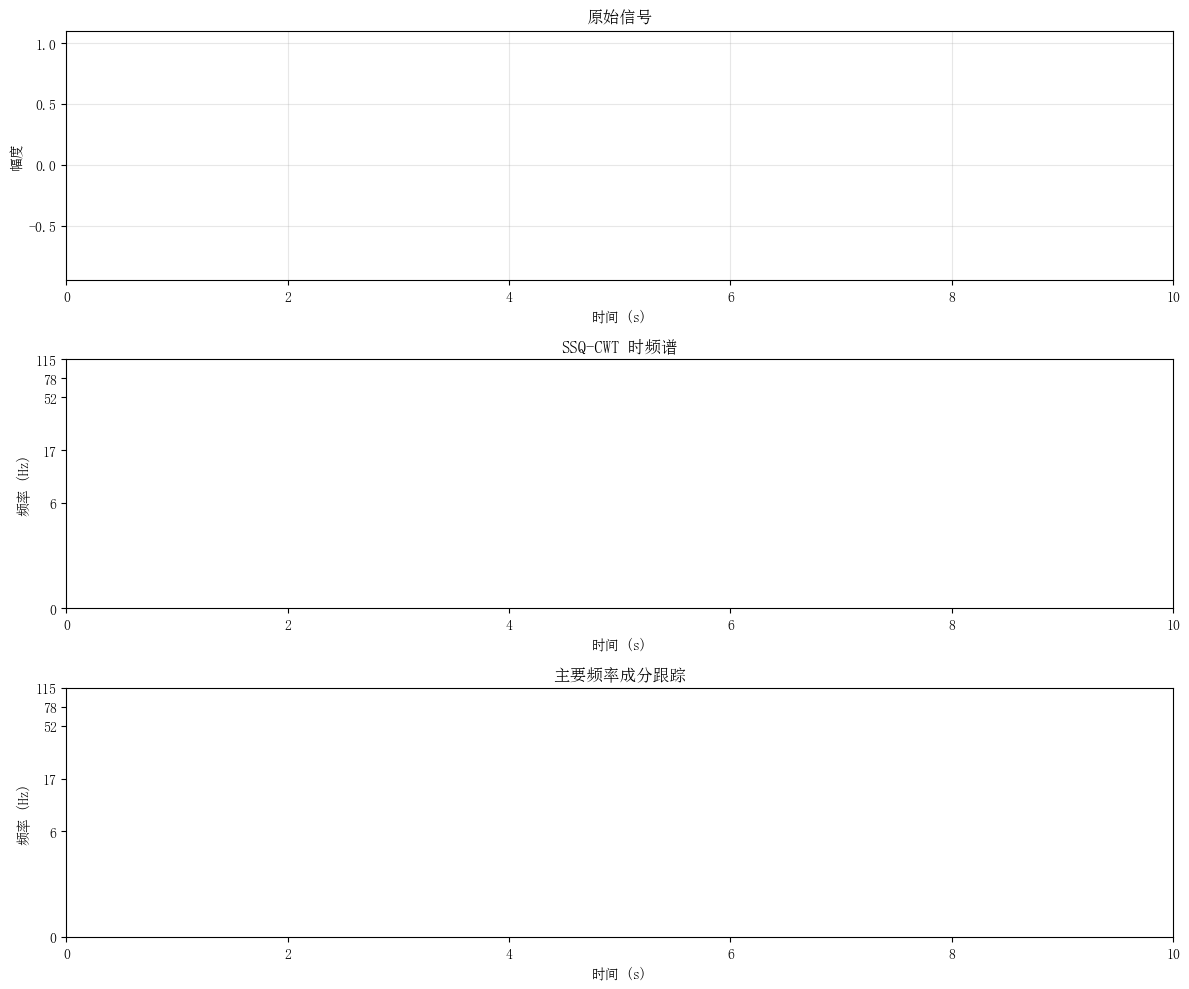

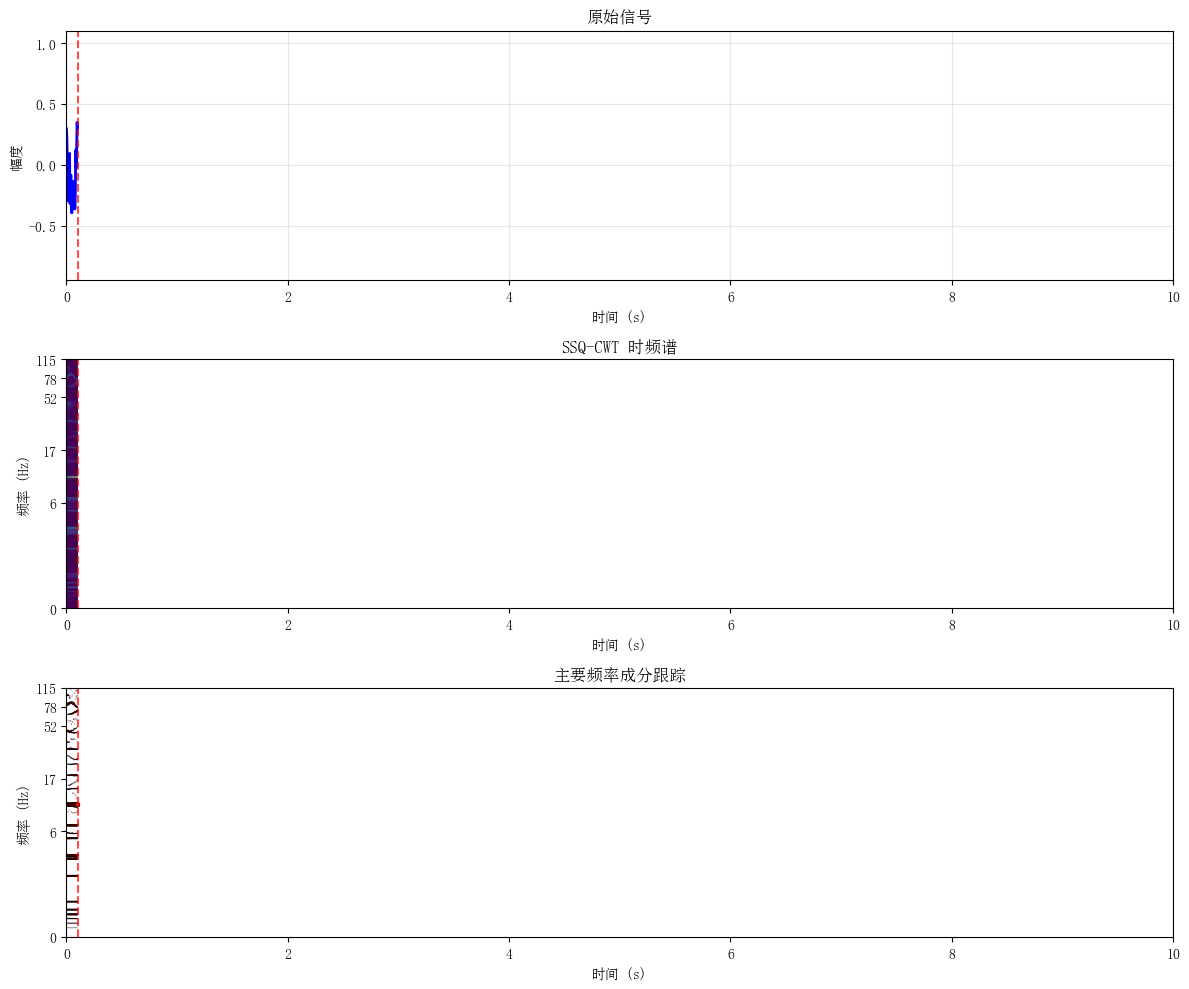

In [16]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from matplotlib.gridspec import GridSpec

# 全局设置中文字体
import matplotlib
matplotlib.rcParams['font.family'] = 'SimSun'
matplotlib.rcParams['font.sans-serif'] = ['SimSun']
matplotlib.rcParams['axes.unicode_minus'] = False

def create_progressive_animation(signal, t, result, fs, scale, freq_points, 
                               total_frames=100, interval=100):
    """
    创建逐帧显示的动画，每帧显示更多的时间点
    
    参数:
    - signal: 原始信号
    - t: 时间轴
    - result: VMD分解结果
    - fs: 采样频率
    - scale: 频率尺度
    - freq_points: 频率点
    - total_frames: 总帧数
    - interval: 动画间隔(毫秒)
    """
    
    # 准备数据
    tf_energy = np.abs(result.tf_map)[0]
    time_tf = np.arange(tf_energy.shape[1]) / fs
    freq_tf = np.linspace(0, fs/2, tf_energy.shape[0])
    
    # 计算每帧显示的时间长度
    total_time = len(signal) / fs
    time_per_frame = total_time / total_frames
    
    # 创建图形
    fig = plt.figure(figsize=(12, 10))
    gs = GridSpec(3, 1, height_ratios=[1, 1, 1])
    
    ax_signal = fig.add_subplot(gs[0])
    ax_tf = fig.add_subplot(gs[1])
    ax_centers = fig.add_subplot(gs[2])
    
    # 设置坐标轴范围
    ax_signal.set_xlim(0, total_time)
    ax_signal.set_ylim(signal.min() * 1.1, signal.max() * 1.1)
    ax_signal.set_title('原始信号')
    ax_signal.set_xlabel('时间 (s)')
    ax_signal.set_ylabel('幅度')
    ax_signal.grid(True, alpha=0.3)
    
    ax_tf.set_xlim(0, total_time)
    ax_tf.set_ylim(freq_tf[0], freq_tf[-1])
    ax_tf.set_title('SSQ-CWT 时频谱')
    ax_tf.set_xlabel('时间 (s)')
    ax_tf.set_ylabel('频率 (Hz)')
    ax_tf.set_yticks(freq_points[[0,100,150,200,218,236]])
    ax_tf.set_yticklabels(np.array(scale[::-1][[0,100,150,200,218,236]], dtype=int))
    
    ax_centers.set_xlim(0, total_time)
    ax_centers.set_ylim(freq_tf[0], freq_tf[-1])
    ax_centers.set_title('主要频率成分跟踪')
    ax_centers.set_xlabel('时间 (s)')
    ax_centers.set_ylabel('频率 (Hz)')
    ax_centers.set_yticks(freq_points[[0,100,150,200,218,236]])
    ax_centers.set_yticklabels(np.array(scale[::-1][[0,100,150,200,218,236]], dtype=int))
    
    # 初始化图形元素
    line_signal, = ax_signal.plot([], [], 'b-', linewidth=2)
    
    # 预处理中心频率数据
    if hasattr(result, 'time_indices') and hasattr(result, 'center_frequencies'):
        center_times = np.array(result.time_indices) / fs
        center_freqs = np.array(result.center_frequencies) * fs/2
        
        # 计算能量用于散点大小
        if hasattr(result, 'mode_functions'):
            mode_energies = _calculate_mode_energies(result.mode_functions)
            normalized_energies = mode_energies / np.max(mode_energies) if len(mode_energies) > 0 else np.ones(len(center_times))
        else:
            normalized_energies = np.ones(len(center_times))
    else:
        center_times = np.array([])
        center_freqs = np.array([])
        normalized_energies = np.array([])
    
    def animate(frame):
        # 计算当前时间点
        current_time = (frame + 1) * time_per_frame
        
        # 清空所有子图
        ax_signal.clear()
        ax_tf.clear()
        ax_centers.clear()
        
        # 重新设置坐标轴（因为clear()会清除设置）
        ax_signal.set_xlim(0, total_time)
        ax_signal.set_ylim(signal.min() * 1.1, signal.max() * 1.1)
        ax_signal.set_title('原始信号')
        ax_signal.set_xlabel('时间 (s)')
        ax_signal.set_ylabel('幅度')
        ax_signal.grid(True, alpha=0.3)
        
        ax_tf.set_xlim(0, total_time)
        ax_tf.set_ylim(freq_tf[0], freq_tf[-1])
        ax_tf.set_title('SSQ-CWT 时频谱')
        ax_tf.set_xlabel('时间 (s)')
        ax_tf.set_ylabel('频率 (Hz)')
        ax_tf.set_yticks(freq_points[[0,100,150,200,218,236]])
        ax_tf.set_yticklabels(np.array(scale[::-1][[0,100,150,200,218,236]], dtype=int))
        
        ax_centers.set_xlim(0, total_time)
        ax_centers.set_ylim(freq_tf[0], freq_tf[-1])
        ax_centers.set_title('主要频率成分跟踪')
        ax_centers.set_xlabel('时间 (s)')
        ax_centers.set_ylabel('频率 (Hz)')
        ax_centers.set_yticks(freq_points[[0,100,150,200,218,236]])
        ax_centers.set_yticklabels(np.array(scale[::-1][[0,100,150,200,218,236]], dtype=int))
        
        # 1. 绘制原始信号（到当前时间点）
        mask_signal = t <= current_time
        if np.any(mask_signal):
            ax_signal.plot(t[mask_signal], signal[mask_signal], 'b-', linewidth=2)
        
        # 2. 绘制时频图（到当前时间点）
        time_mask = time_tf <= current_time
        if np.any(time_mask):
            # 只显示到当前时间的时频数据
            current_tf = tf_energy[:, time_mask]
            current_time_tf = time_tf[time_mask]
            
            if current_tf.size > 0:
                im = ax_tf.pcolormesh(current_time_tf, freq_tf, current_tf,
                                    cmap='viridis', shading='gouraud')
        
        # 3. 绘制中心频率（到当前时间点）
        if len(center_times) > 0:
            center_mask = center_times <= current_time
            if np.any(center_mask):
                current_center_times = center_times[center_mask]
                current_center_freqs = center_freqs[center_mask]
                current_energies = normalized_energies[center_mask] if len(normalized_energies) > 0 else np.ones(len(current_center_times))
                
                # 绘制背景
                ax_centers.pcolormesh(time_tf[time_tf <= current_time], freq_tf, 
                                    np.zeros((len(freq_tf), np.sum(time_tf <= current_time))),
                                    cmap='Greys', alpha=0.1)
                
                # 绘制散点
                scatter_sizes = current_energies * 50  # 基础大小
                ax_centers.scatter(current_center_times, current_center_freqs,
                                 s=scatter_sizes,
                                 c='red',
                                 alpha=0.8,
                                 edgecolors='black',
                                 linewidth=0.5)
        
        # 添加当前时间的竖线指示
        ax_signal.axvline(x=current_time, color='red', linestyle='--', alpha=0.7)
        ax_tf.axvline(x=current_time, color='red', linestyle='--', alpha=0.7)
        ax_centers.axvline(x=current_time, color='red', linestyle='--', alpha=0.7)
        
    # 创建动画
    anim = animation.FuncAnimation(fig, animate, frames=total_frames,
                                 interval=interval, blit=False, repeat=True)
    
    plt.tight_layout()
    return fig, anim

def save_progressive_animation(signal, t, result, fs, scale, freq_points, 
                             filename='progressive_animation.gif', 
                             fps=10, total_frames=100):
    """
    保存逐帧动画
    """
    fig, anim = create_progressive_animation(signal, t, result, fs, scale, freq_points,
                                           total_frames=total_frames, 
                                           interval=1000/fps)
    
    # 保存动画
    if filename.endswith('.gif'):
        anim.save(filename, writer='pillow', fps=fps)
    elif filename.endswith('.mp4'):
        anim.save(filename, writer='ffmpeg', fps=fps)
    
    return fig, anim

# 调用函数创建动画
fig, anim = create_progressive_animation(signal, t, result, fs, scale, freq_points,
                                       total_frames=100,  # 总帧数
                                       interval=100)      # 每帧间隔100毫秒

# 显示动画
plt.show()

# 保存动画（取消注释使用）
fig_save, anim_save = save_progressive_animation(signal, t, result, fs, scale, freq_points,
                                               'progressive_tf.gif', fps=10, total_frames=100)